Original shape: 2,000 rows x 11 columns

Column names and data types:


,column,dtype,missing,unique
0,Car_ID,int64,0,2000
1,Brand,object,0,6
2,Model_Year,int64,0,19
3,Engine_Size,float64,0,41
4,Fuel_Type,object,0,4
5,Transmission,object,0,2
6,Mileage,int64,0,1989
7,Doors,int64,0,3
8,Owner_Count,int64,0,4
9,Horsepower,int64,0,329



Sample records:


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


Duplicate rows before cleaning: 0
Missing values before cleaning:


...

,count
Brand,
Toyota,352
Hyundai,337
Tesla,330
Honda,329
Ford,326
Bmw,326



Fuel_Type:


,count
Fuel_Type,
Diesel,537
Petrol,511
Electric,484
Hybrid,468



Transmission:


,count
Transmission,
Automatic,1018
Manual,982


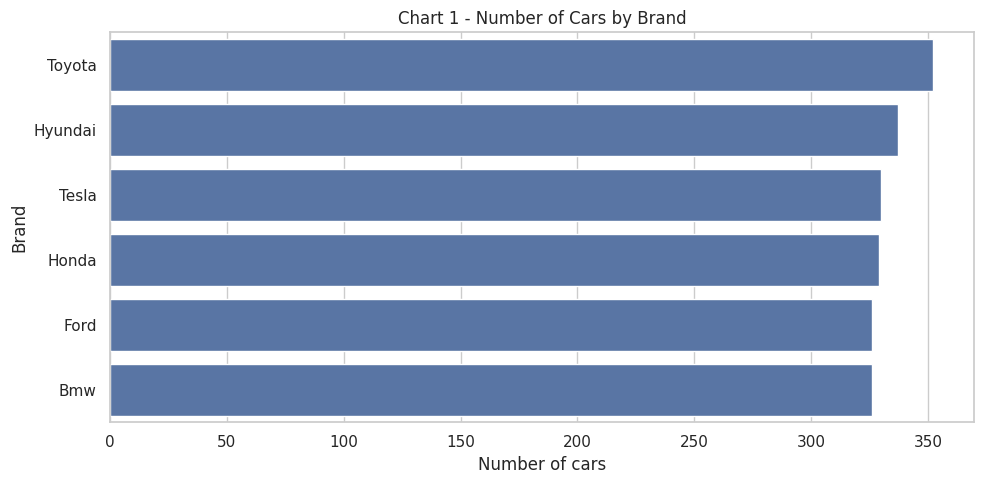

Observation: The bars show which brands are most represented; this describes dataset composition and should not be interpreted as market share.


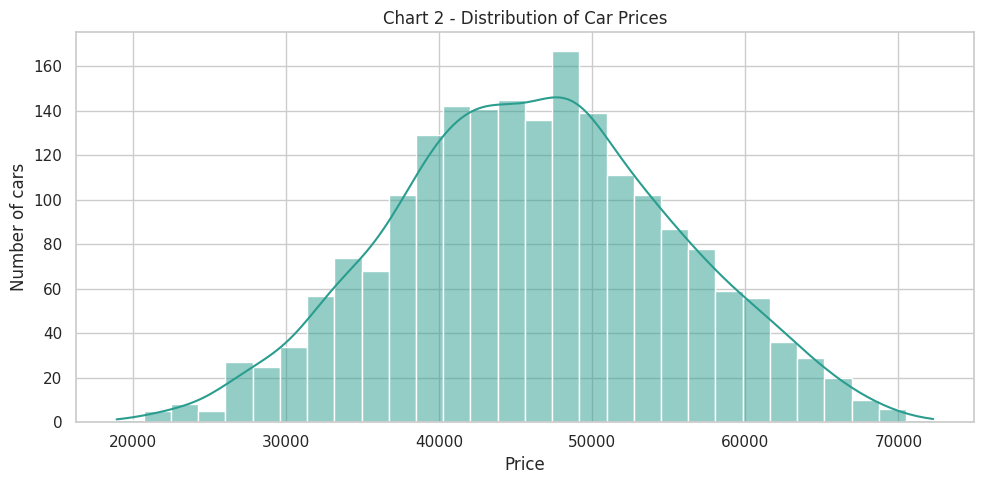

Observation: Prices range from 18,911.55 to 72,267.80, with a median of 46,112.35.


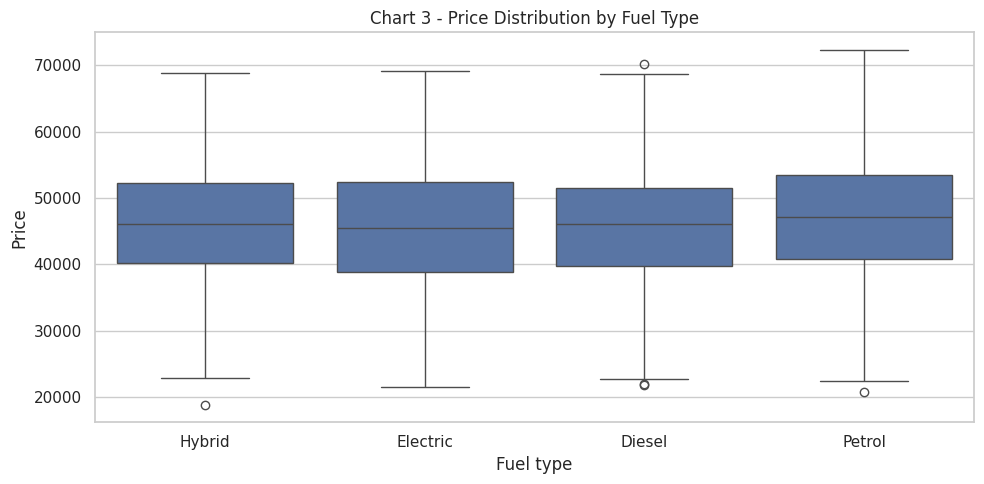

Observation: The box plots compare medians, spread, and potential price outliers across fuel categories.


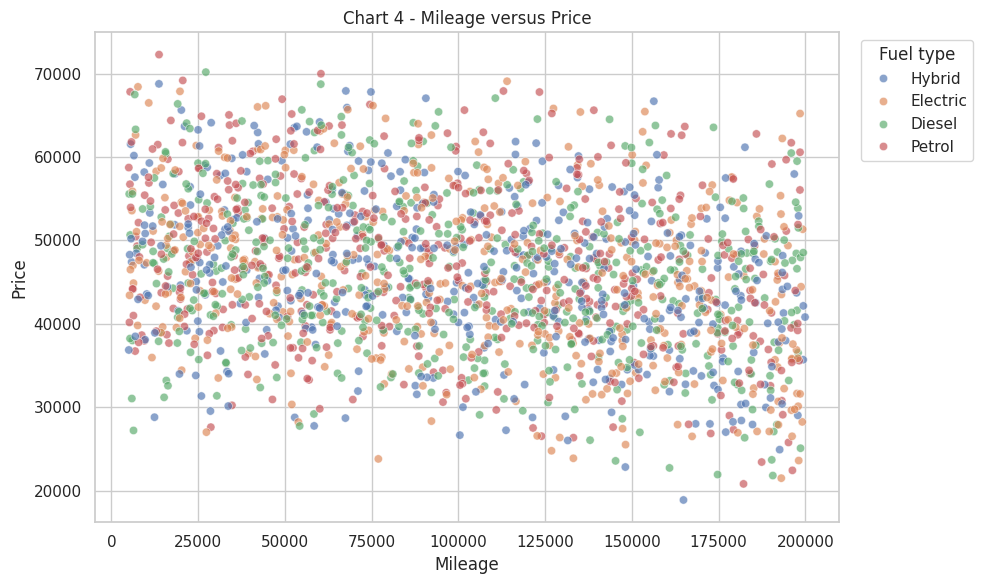

Observation: The mileage-price Pearson correlation is -0.27; the sign and strength quantify the overall linear relationship.


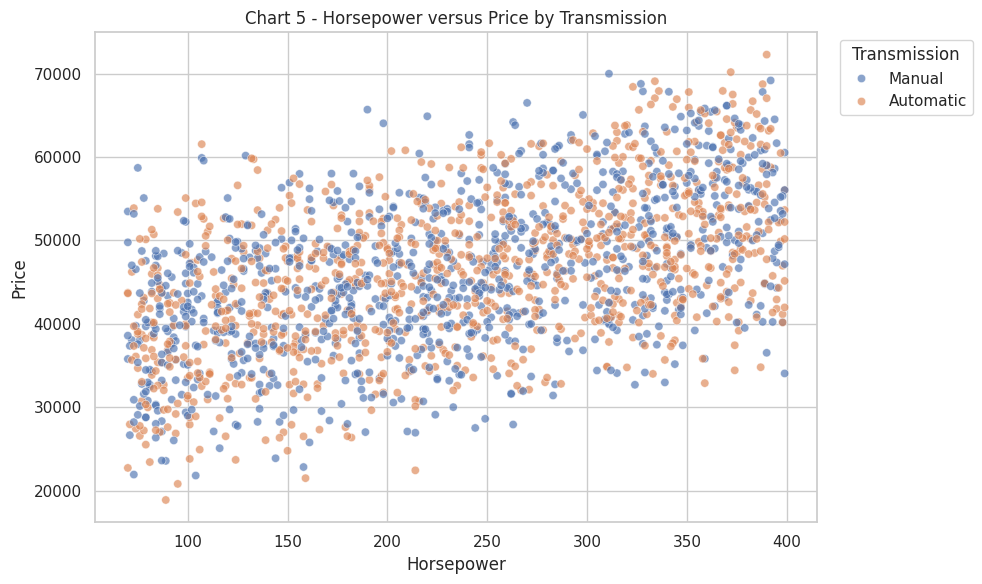

Observation: Horsepower-price Pearson correlation is 0.51; transmission colours show whether the relationship appears similar across groups.


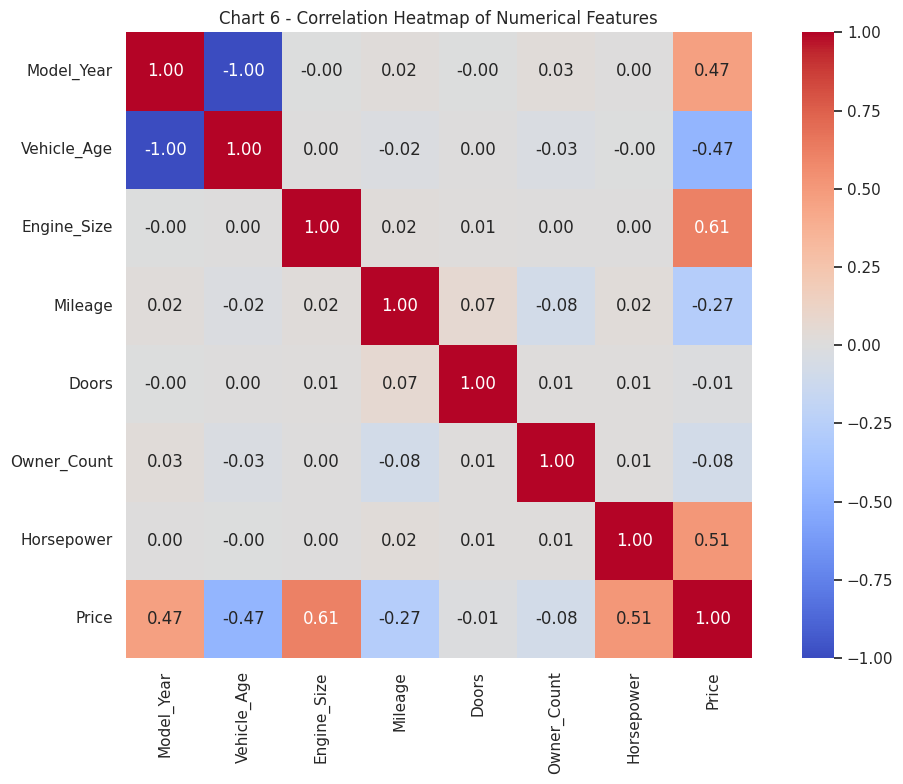

Observation: The heatmap summarises pairwise linear relationships and helps identify features that merit deeper investigation.
Key findings:
1. The dataset contains 2,000 usable vehicles across 6 brands, 4 fuel types, and 2 transmission categories.
2. The most common brand is Toyota, representing 352 records (17.6% of the cleaned dataset).
3. The highest average price is observed for Honda (46,584.09); this is a descriptive difference within this dataset, not a causal conclusion.
4. Vehicle age and price have a Pearson correlation of -0.47, while mileage and price have a correlation of -0.27.
5. The strongest average price among fuel categories is Petrol (47,132.05); category counts should be considered when interpreting this comparison.
6. The transmission group with the higher average price is Automatic (46,265.15).
7. There are 2 price observations outside the 1.5×IQR rule; they were retained because outliers may be genuine vehicles and the assignment requires justified treatment.



,mean,median,count
Brand,,,
Honda,46584.09,45286.50,329
Toyota,46341.71,47373.98,352
Bmw,46206.12,46551.60,326
Ford,46135.08,45632.50,326
Tesla,46123.82,46149.68,330
Hyundai,45627.52,45158.55,337


Average price by fuel type:


,mean,median,count
Fuel_Type,,,
Petrol,47132.05,47160.45,511
Hybrid,46004.61,46123.85,468
Diesel,45810.23,46016.05,537
Electric,45711.34,45470.28,484


Average price by transmission:


,mean,median,count
Transmission,,,
Automatic,46265.15,46369.95,1018
Manual,46070.36,45712.55,982


### Limitations
- The file is an observational dataset; associations do not establish causation.
- The dataset source and collection process are not included in the CSV, so representativeness cannot be verified.
- Price may depend on omitted variables such as trim, location, condition, service history, and equipment.
- Category sizes differ, so small groups should be interpreted cautiously.

### Conclusion
This EDA establishes a clean, documented baseline for understanding car prices and their relationships with vehicle age, mileage, horsepower, fuel type, transmission, and brand. The strongest follow-up would be a model or stratified analysis that adds vehicle condition, trim, location, and other market variables if they become available.

In [ ]:
# Cars Exploratory Data Analysis Project
# Dataset: car_price_dataset.csv (uploaded to the Colab session)

import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = '/content/car_price_dataset.csv'
assert os.path.exists(DATA_PATH), f'Dataset not found at {DATA_PATH}'

# 1. Load and understand the dataset
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print(f'Original shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print('\nColumn names and data types:')
display(pd.DataFrame({'column': df.dtypes.index, 'dtype': df.dtypes.astype(str).values, 'missing': df.isna().sum().values, 'unique': df.nunique().values}))
print('\nSample records:')
display(df.head())

# 2. Data quality checks and cleaning
print('Duplicate rows before cleaning:', df.duplicated().sum())
print('Missing values before cleaning:')
display(df.isna().sum().to_frame('missing_count').query('missing_count > 0'))

# Standardise text fields and enforce numeric types where appropriate
text_cols = ['Brand', 'Fuel_Type', 'Transmission']
for col in text_cols:
    df[col] = df[col].astype('string').str.strip().str.title()

numeric_cols = ['Car_ID', 'Model_Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

rows_before = len(df)
df = df.drop_duplicates().copy()
df = df.dropna(subset=['Brand', 'Model_Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']).copy()
# Remove only physically impossible values; keep plausible high/low observations for analysis
valid = (df['Model_Year'].between(1900, 2030) & (df['Engine_Size'] > 0) & (df['Mileage'] >= 0) &
         (df['Doors'].between(2, 6)) & (df['Owner_Count'] >= 0) & (df['Horsepower'] > 0) & (df['Price'] > 0))
df = df.loc[valid].copy()

# Derived features used for analysis
reference_year = int(df['Model_Year'].max())
df['Vehicle_Age'] = reference_year - df['Model_Year']

print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning:  {len(df):,}')
print(f'Rows removed:         {rows_before - len(df):,}')
print('Missing values after cleaning:', int(df.isna().sum().sum()))
print('Duplicate rows after cleaning:', int(df.duplicated().sum()))
print('\nCleaned data preview:')
display(df.head())

# 3. Descriptive statistics
print('Numerical descriptive statistics:')
display(df[['Model_Year', 'Vehicle_Age', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']].describe().T.round(2))

print('Categorical distributions:')
for col in text_cols:
    print(f'\n{col}:')
    display(df[col].value_counts().rename('count').to_frame())

# 4. Visual EDA - six meaningful charts across five chart types
# Chart 1: bar/count plot
plt.figure(figsize=(10, 5))
brand_order = df['Brand'].value_counts().index
sns.countplot(data=df, y='Brand', order=brand_order)
plt.title('Chart 1 - Number of Cars by Brand')
plt.xlabel('Number of cars'); plt.ylabel('Brand'); plt.tight_layout(); plt.show()
print('Observation: The bars show which brands are most represented; this describes dataset composition and should not be interpreted as market share.')

# Chart 2: histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Price', bins=30, kde=True, color='#2a9d8f')
plt.title('Chart 2 - Distribution of Car Prices')
plt.xlabel('Price'); plt.ylabel('Number of cars'); plt.tight_layout(); plt.show()
print(f'Observation: Prices range from {df.Price.min():,.2f} to {df.Price.max():,.2f}, with a median of {df.Price.median():,.2f}.')

# Chart 3: box plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Price')
plt.title('Chart 3 - Price Distribution by Fuel Type')
plt.xlabel('Fuel type'); plt.ylabel('Price'); plt.tight_layout(); plt.show()
print('Observation: The box plots compare medians, spread, and potential price outliers across fuel categories.')

# Chart 4: scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Mileage', y='Price', hue='Fuel_Type', alpha=0.65)
plt.title('Chart 4 - Mileage versus Price')
plt.xlabel('Mileage'); plt.ylabel('Price'); plt.legend(title='Fuel type', bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()
print(f'Observation: The mileage-price Pearson correlation is {df.Mileage.corr(df.Price):.2f}; the sign and strength quantify the overall linear relationship.')

# Chart 5: scatter plot with a second relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Horsepower', y='Price', hue='Transmission', alpha=0.65)
plt.title('Chart 5 - Horsepower versus Price by Transmission')
plt.xlabel('Horsepower'); plt.ylabel('Price'); plt.legend(title='Transmission', bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()
print(f'Observation: Horsepower-price Pearson correlation is {df.Horsepower.corr(df.Price):.2f}; transmission colours show whether the relationship appears similar across groups.')

# Chart 6: heatmap
plt.figure(figsize=(11, 8))
correlation_cols = ['Model_Year', 'Vehicle_Age', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower', 'Price']
sns.heatmap(df[correlation_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Chart 6 - Correlation Heatmap of Numerical Features')
plt.tight_layout(); plt.show()
print('Observation: The heatmap summarises pairwise linear relationships and helps identify features that merit deeper investigation.')

# 5. Evidence-based findings
brand_price = df.groupby('Brand')['Price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
fuel_price = df.groupby('Fuel_Type')['Price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
trans_price = df.groupby('Transmission')['Price'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

price_q1, price_q3 = df.Price.quantile([0.25, 0.75])
price_iqr = price_q3 - price_q1
price_outliers = df[(df.Price < price_q1 - 1.5*price_iqr) | (df.Price > price_q3 + 1.5*price_iqr)]

findings = [
    f"The dataset contains {len(df):,} usable vehicles across {df.Brand.nunique()} brands, {df.Fuel_Type.nunique()} fuel types, and {df.Transmission.nunique()} transmission categories.",
    f"The most common brand is {df.Brand.mode().iat[0]}, representing {int(df.Brand.value_counts().iloc[0])} records ({100*df.Brand.value_counts().iloc[0]/len(df):.1f}% of the cleaned dataset).",
    f"The highest average price is observed for {brand_price.index[0]} ({brand_price.iloc[0]['mean']:,.2f}); this is a descriptive difference within this dataset, not a causal conclusion.",
    f"Vehicle age and price have a Pearson correlation of {df.Vehicle_Age.corr(df.Price):.2f}, while mileage and price have a correlation of {df.Mileage.corr(df.Price):.2f}.",
    f"The strongest average price among fuel categories is {fuel_price.index[0]} ({fuel_price.iloc[0]['mean']:,.2f}); category counts should be considered when interpreting this comparison.",
    f"The transmission group with the higher average price is {trans_price.index[0]} ({trans_price.iloc[0]['mean']:,.2f}).",
    f"There are {len(price_outliers)} price observations outside the 1.5×IQR rule; they were retained because outliers may be genuine vehicles and the assignment requires justified treatment.",
    f"Horsepower and price have a Pearson correlation of {df.Horsepower.corr(df.Price):.2f}, providing a useful multivariate-analysis starting point alongside engine size and vehicle age."
]

print('Key findings:')
for i, finding in enumerate(findings[:7], start=1):
    print(f'{i}. {finding}')

print('\nSupporting group summaries:')
print('Average price by brand:'); display(brand_price.round(2))
print('Average price by fuel type:'); display(fuel_price.round(2))
print('Average price by transmission:'); display(trans_price.round(2))

# 6. Limitations and conclusion
display(Markdown('''### Limitations
- The file is an observational dataset; associations do not establish causation.
- The dataset source and collection process are not included in the CSV, so representativeness cannot be verified.
- Price may depend on omitted variables such as trim, location, condition, service history, and equipment.
- Category sizes differ, so small groups should be interpreted cautiously.

### Conclusion
This EDA establishes a clean, documented baseline for understanding car prices and their relationships with vehicle age, mileage, horsepower, fuel type, transmission, and brand. The strongest follow-up would be a model or stratified analysis that adds vehicle condition, trim, location, and other market variables if they become available.'''))
